###install necessary libraries

In [3]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

###read csv data from spam.csv file, encoding added as some messages were corrupted with regular default encoding

In [5]:
df = pd.read_csv("spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


###change v1, v2 column name to label and messages

In [6]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


###change ham and spam language to 0 and 1 where ham is 0 and spam is 1

In [7]:
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Text Preprocessing where we are doing lowercasing, remove HTML tags, remove puncutation, remove numbers, and stopwords removal as well.

In [8]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = remove_html_tags(text)
    text = re.sub(r'[\W_]+', ' ', text)
    text = re.sub(r'\d+', '', text)
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    text = ' '.join(filtered_words)
    return text.strip()
df['message'] = df['message'].apply(preprocess_text)

display(df.head())

,label,message
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry wkly comp win fa cup final tkts st ...
3,0,u dun say early hor u c already say
4,0,nah think goes usf lives around though


###check for data distributions for spam messages or not

In [19]:
label_counts = df['label'].value_counts()

print("Distribution of spam or not:")
print(label_counts)

Distribution of spam or not:
label
0    4825
1     747
Name: count, dtype: int64


In [9]:
df_cleaned = df.dropna(subset=['label'])
X_train, X_test, y_train, y_test = train_test_split(
    df_cleaned['message'],
    df_cleaned['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_cleaned['label']
)

In [10]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [11]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

In [20]:
print("logistic regression results")
print("accuracy :", accuracy_score(y_test, y_pred_lr))
print("precision:", precision_score(y_test, y_pred_lr))
print("recall   :", recall_score(y_test, y_pred_lr))
print("f1 Score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

logistic regression results
accuracy : 0.968609865470852
precision: 0.9913793103448276
recall   : 0.7718120805369127
f1 Score : 0.8679245283018868

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [13]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [14]:
print("Naive Bayes Results")
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results
Accuracy : 0.968609865470852
Precision: 0.9913793103448276
Recall   : 0.7718120805369127
F1 Score : 0.8679245283018868

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



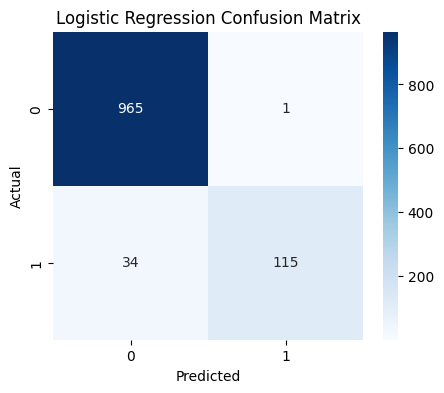

In [15]:
map = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(map, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
stop_words = stopwords.words('english')

tfidf_stop = TfidfVectorizer(
    stop_words=stop_words
)

X_train_stop = tfidf_stop.fit_transform(X_train)
X_test_stop = tfidf_stop.transform(X_test)

lr_stop = LogisticRegression(max_iter=1000)

lr_stop.fit(X_train_stop, y_train)

y_pred_stop = lr_stop.predict(X_test_stop)

print("With Stopword Removal")
print("Precision:", precision_score(y_test, y_pred_stop))
print("Recall   :", recall_score(y_test, y_pred_stop))
print("F1 Score :", f1_score(y_test, y_pred_stop))

With Stopword Removal
Precision: 0.9913793103448276
Recall   : 0.7718120805369127
F1 Score : 0.8679245283018868


In [17]:
tfidf_ngram = TfidfVectorizer(
    ngram_range=(1,2)
)

X_train_ngram = tfidf_ngram.fit_transform(X_train)
X_test_ngram = tfidf_ngram.transform(X_test)

lr_ngram = LogisticRegression(max_iter=1000)

lr_ngram.fit(X_train_ngram, y_train)

y_pred_ngram = lr_ngram.predict(X_test_ngram)

print("Using Unigrams + Bigrams")
print("Precision:", precision_score(y_test, y_pred_ngram))
print("Recall   :", recall_score(y_test, y_pred_ngram))
print("F1 Score :", f1_score(y_test, y_pred_ngram))

Using Unigrams + Bigrams
Precision: 0.990990990990991
Recall   : 0.738255033557047
F1 Score : 0.8461538461538461


its only in precision that naive bayes performs well, in all other evaluation meterics we see that TF-IDF with logistic regression performs better

using unigrams and bigrams and stopword removal does not hamper our performance in any meaningful manner